In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import glob
import blimpy as bl
%matplotlib inline

In [2]:
bliss_tvec = [1028.2914798259735, 1521.8434946537018-1028.2914798259735, 1783.5242681503296-1521.8434946537018, 179.17646312713623]
print(bliss_tvec)
seticore_t = 67.52513003349304
seticore_c = 72

[1028.2914798259735, 493.55201482772827, 261.6807734966278, 179.17646312713623]


In [5]:
bliss_cvec = []
bliss_dats = glob.glob('/datax/scratch/benjb/bliss_LSCX_test/blc44_guppi_60233_38409_GJ144_0016.rawspec.0000_nosig_nosk_*L1_30.dat')
for dat in bliss_dats:
    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
    ff = df['freq_start'].values
    dd = df['Drift_Rate'].values
    ss = df['SNR'].values
    bliss_cvec.append(len(ff))

In [6]:
print(bliss_cvec)

[4883, 5838, 3115, 279]


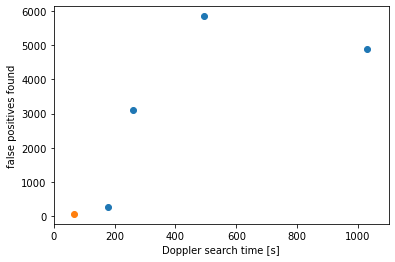

In [7]:
plt.scatter(bliss_tvec, bliss_cvec)
plt.scatter(seticore_t, seticore_c)
plt.xlabel('Doppler search time [s]')
plt.ylabel('false positives found')
plt.xlim(0,1100)
#plt.yscale('log')
#plt.xscale('log')
plt.show()

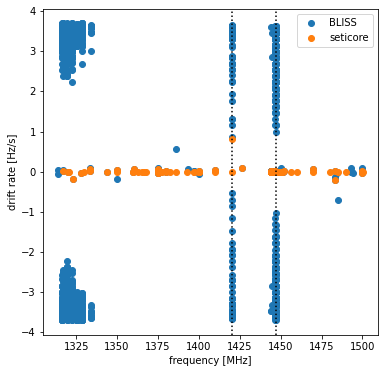

In [8]:
dat = '/datax/scratch/benjb/bliss_LSCX_test/blc44_guppi_60233_38409_GJ144_0016.rawspec.0000_nosig_nosk_SNR_20_L1_30.dat'
df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
bf = df['freq_start'].values
bd = df['Drift_Rate'].values
bs = df['SNR'].values
dat = '/datax/scratch/benjb/bliss_LSCX_test/blc44_guppi_60233_38409_GJ144_0016.rawspec.0000.6_seticore.dat'
df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
tf = df['freq_start'].values
td = df['Drift_Rate'].values
ts = df['SNR'].values
fig, ax = plt.subplots(1,1,figsize=(6,6))
plt.scatter(bf, bd, label='BLISS')
plt.scatter(tf, td, label='seticore')
plt.axvline(1420.36, color='k', ls=':')
plt.axvline(1446.9, color='k', ls=':')
plt.xlabel('frequency [MHz]')
plt.ylabel('drift rate [Hz/s]')
#plt.xlim(1322,1329)
plt.legend()
plt.show()

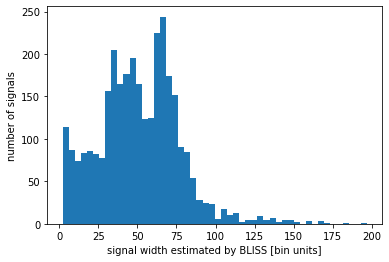

In [9]:
dat = '/datax/scratch/benjb/bliss_LSCX_test/blc44_guppi_60233_38409_GJ144_0016.rawspec.0000_nosig_nosk_SNR_20_L1_30.dat'
df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
widths = df['Full_number_of_hits'].values
widths = df['Full_number_of_hits'].values
ff = df['freq_start'].values
w1325 = widths[np.where(ff < 1350)[0]]
w1420 = widths[np.where((ff < 1430) & (ff > 1400))[0]]
plt.hist(widths, bins=50)
#plt.hist(w1325, histtype='step', bins=50)
#plt.hist(w1420, histtype='step', bins=50)
plt.xlabel('signal width estimated by BLISS [bin units]')
plt.ylabel('number of signals')
plt.show()

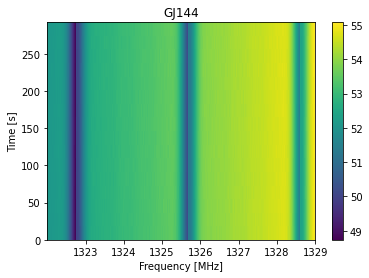

In [10]:
h5 = '/datag/pipeline/AGBT23A_999_43/blc44_blp04/blc44_guppi_60233_38409_GJ144_0016.rawspec.0000.h5'
fb = bl.Waterfall(h5,
                  f_start=1322,
                  f_stop=1329
                  )
fb.plot_waterfall()

extracting integration 0...


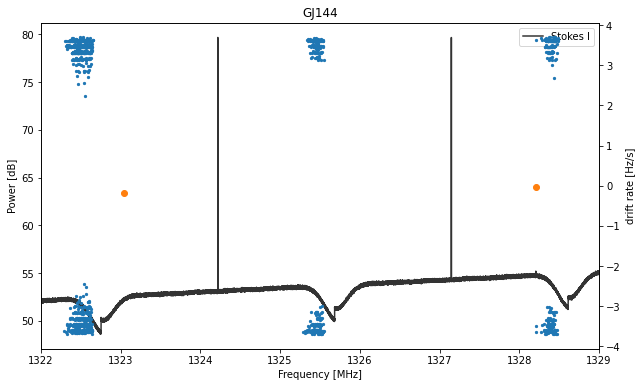

In [11]:
fig = plt.figure(figsize=(10,6))
fb.plot_spectrum(logged=True)
ax = fig.gca().twinx()
ax.scatter(bf, bd, label='BLISS', s=5)
ax.scatter(tf, td, label='seticore')
ax.axvline(1420.36, color='k', ls=':')
ax.axvline(1446.9, color='k', ls=':')
plt.xlabel('frequency [MHz]')
plt.ylabel('drift rate [Hz/s]')
plt.xlim(1322,1329)
#plt.legend()
plt.show()

In [137]:
print(fff[::-1][269834])
print(fff[::-1][269834+2**20])

1322.7539090439677
1325.6835965439677


In [134]:
fff, _ = fb.grab_data(f_start=1322, f_stop=1329)

In [135]:
print(len(fff))
print(64*2**20)
print(fff)

2505398
67108864
[1328.99999991 1328.99999712 1328.99999432 ... 1322.00000715 1322.00000435
 1322.00000156]


extracting integration 0...


(60000.0, 130000.0)

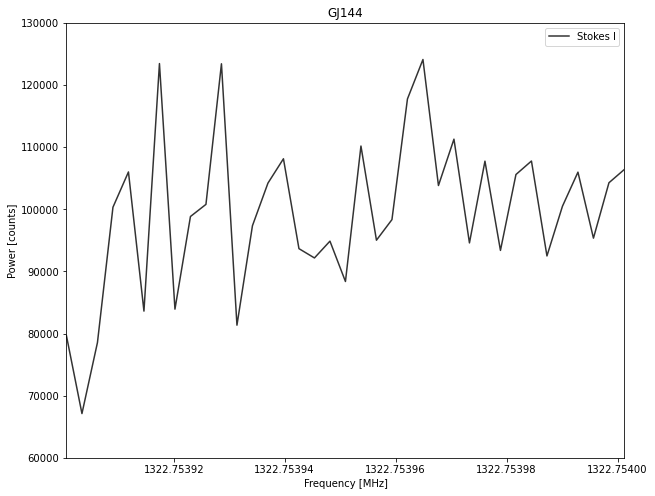

In [125]:
fig = plt.figure(figsize=(10,8))
fb.plot_spectrum(f_start=1322.7539, f_stop=1322.7540)
plt.ylim(60000,130000)

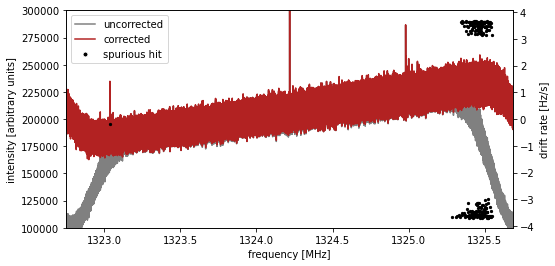

In [21]:
cc1 = np.average(np.squeeze(fb.data), axis=0)[::-1][269834:269834+2**20]
fig, ax = plt.subplots(figsize=(8,4))
p1 = ax.plot(np.linspace(1322.7539090439677, 1325.6835965439677, 2**20), cc1, color='gray', label='uncorrected')
pfb = np.fromfile('/datax/scratch/benjb/bliss_LSCX_test/0_0_GBT_channelizer_response.f32', dtype='float32')
from astropy.stats import sigma_clip
clipped_data = sigma_clip(cc1,
                        sigma=3,
                        maxiters=5,
                        masked=False)
noise_mean = np.mean(clipped_data)
noise_std = np.std(clipped_data)
p2 = ax.plot(np.linspace(1322.7539090439677, 1325.6835965439677, 2**20), cc1/pfb, color='firebrick', label='corrected')
#plt.axhspan(noise_mean-noise_std, noise_mean+noise_std, alpha=0.2, color='k', lw=0)
#plt.axhline(noise_mean, color='k')
#plt.yscale('log')
ax2 = fig.gca().twinx()
s=ax2.scatter(bf, bd, s=5, c='k', label='spurious hit')
ax.set_xlim(1322.7539090439677, 1325.6835965439677)
#ax.set_xlim(1325.2, 1325.6835965439677)
ax.set_ylim(1e5, 3e5)
ax.set_xlabel('frequency [MHz]')
ax.set_ylabel('intensity [arbitrary units]')
ax2.set_ylabel('drift rate [Hz/s]')
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='gray', label='uncorrected'),
    Line2D([0], [0], color='firebrick', label='corrected'),
    Line2D([0], [0], marker='o', color='w', label='spurious hit',
                          markerfacecolor='k', markersize=5)
]
plt.legend(handles = custom_lines, loc='upper left')
plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/pfb_flaring.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import numpy.polynomial.polynomial as poly
from scipy.interpolate import UnivariateSpline

x = np.linspace(1322.7539090439677, 1325.6835965439677, 2**20)
x_new = np.linspace(1322.7539090439677, 1325.6835965439677, 2**6)
y = cc1/pfb
y[np.argmax(y)] = np.mean(y)
cs = UnivariateSpline(x[::4], y[::4])

coefs = poly.polyfit(x, y, 31)
ffit = poly.polyval(x_new, coefs)
plt.plot(x, y)
plt.plot(x_new, ffit)
plt.plot(x_new, cs(x_new))

#plt.ylim(1e5, 3e5)
plt.yscale('log')
plt.show()